# 🍎🍌🍊 PeekMyFruit — Training di Google Colab

Notebook ini melatih model deteksi kematangan buah (Unripe / Ripe / Rotten)
dengan MobileNetV2.

**Cara pakai:** jalankan setiap sel berurutan dari atas ke bawah dengan menekan
tombol ▶ di kiri sel (atau Shift+Enter). Tunggu satu sel selesai sebelum
menjalankan sel berikutnya.


## Langkah 1 — Aktifkan GPU (PENTING, jangan dilewati)

Di menu atas: **Runtime → Change runtime type → Hardware accelerator → pilih T4 GPU → Save.**

Lalu jalankan sel di bawah untuk memastikan GPU aktif. Hasilnya harus
menampilkan sebuah perangkat GPU (bukan list kosong `[]`).

In [ ]:
import tensorflow as tf
print("Versi TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPU terdeteksi:", gpus)
if not gpus:
    print("\n PERINGATAN: GPU belum aktif. Ulangi Runtime > Change runtime type > T4 GPU.")


Versi TensorFlow: 2.20.0
GPU terdeteksi: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Langkah 2 — Masukkan token Kaggle (kaggle.json)

Supaya Colab bisa men-download dataset langsung dari Kaggle, kita butuh file
kunci bernama **kaggle.json**. Cara mengambilnya:

1. Buka https://www.kaggle.com dan login.
2. Klik foto profil (kanan atas) → **Settings**.
3. Scroll ke bagian **API** → klik **Create New Token**.
4. Sebuah file **kaggle.json** otomatis ter-download ke laptopmu.

Lalu jalankan sel di bawah. Akan muncul tombol **Choose Files** —
pilih file **kaggle.json** yang baru saja kamu download.

In [ ]:
from google.colab import files
print("Klik 'Choose Files' lalu pilih kaggle.json dari komputermu:")
uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("\nToken Kaggle siap.")


Klik 'Choose Files' lalu pilih kaggle.json dari komputermu:


Saving kaggle.json to kaggle.json

Token Kaggle siap.


## Langkah 3 — Download dataset dari Kaggle

Ukurannya sekitar 4 GB, tapi karena jaringan Google sangat cepat, ini hanya
butuh beberapa menit. Tunggu sampai muncul tulisan 'Download & unzip selesai.'

In [ ]:
!pip install -q kaggle
!mkdir -p /content/PeekMyFruit/data/raw
!kaggle datasets download -d leftin/fruit-ripeness-unripe-ripe-and-rotten \
    -p /content/PeekMyFruit/data/raw --unzip
print("Download & unzip selesai.")


Dataset URL: https://www.kaggle.com/datasets/leftin/fruit-ripeness-unripe-ripe-and-rotten
License(s): CC-BY-SA-4.0
100% 3.63G/3.63G [00:35<00:00, 111MB/s]

Download & unzip selesai.


## Langkah 4 — Lihat struktur folder dataset (sekadar memastikan)

Sel ini menampilkan nama-nama folder di dalam dataset. Tidak wajib dipahami,
tapi berguna kalau nanti ada yang aneh.

In [ ]:
import os
RAW = "/content/PeekMyFruit/data/raw"
for root, dirs, fnames in os.walk(RAW):
    depth = root.replace(RAW, "").count(os.sep)
    if depth <= 2:
        print("  " * depth + os.path.basename(root) + f"  ({len(fnames)} file)")


raw  (0 file)
  fruit_ripeness_dataset  (0 file)
    archive (1)  (0 file)


## Langkah 5 — Preprocessing & split (train / val / test)

Menggabungkan semua buah ke 3 kelas kematangan. Catatan: kategori 'Fresh' di
dataset ini dihitung sebagai **ripe** (matang).

In [ ]:
import shutil
from pathlib import Path
from sklearn.model_selection import train_test_split

RAW = Path("/content/PeekMyFruit/data/raw")
PROC = Path("/content/PeekMyFruit/data/processed")
CLASS_NAMES = ["ripe", "rotten", "unripe"]
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
SEED = 42
TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.70, 0.15, 0.15

def infer_class(p):
    p = p.lower()
    if "unripe" in p:               # cek unripe dulu (mengandung kata 'ripe')
        return "unripe"
    if "rotten" in p:
        return "rotten"
    if "ripe" in p or "fresh" in p: # 'fresh' = matang di dataset ini
        return "ripe"
    return None

# Kumpulkan gambar per kelas
buckets = {c: [] for c in CLASS_NAMES}
skipped = 0
for path in RAW.rglob("*"):
    if not path.is_file() or path.suffix.lower() not in IMG_EXT:
        continue
    lbl = infer_class(str(path))
    if lbl is None:
        skipped += 1
        continue
    buckets[lbl].append(path)

print("Gambar dilewati (tak terklasifikasi):", skipped)
for c in CLASS_NAMES:
    print(f"  {c:8s}: {len(buckets[c])} gambar")

# Split + salin ke folder processed
if PROC.exists():
    shutil.rmtree(PROC)

def split(files):
    tr, temp = train_test_split(files, train_size=TRAIN_RATIO, random_state=SEED, shuffle=True)
    rel = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
    va, te = train_test_split(temp, train_size=rel, random_state=SEED, shuffle=True)
    return tr, va, te

def copy(files, dest):
    dest.mkdir(parents=True, exist_ok=True)
    for i, s in enumerate(files):
        shutil.copy2(s, dest / f"{i:05d}_{s.name}")

print("\nSplit per kelas:")
for c in CLASS_NAMES:
    if not buckets[c]:
        print(f"  PERINGATAN: kelas '{c}' kosong!")
        continue
    tr, va, te = split(buckets[c])
    copy(tr, PROC / "train" / c)
    copy(va, PROC / "val" / c)
    copy(te, PROC / "test" / c)
    print(f"  {c:8s}: train {len(tr)}  val {len(va)}  test {len(te)}")
print("\nPreprocessing selesai.")


Gambar dilewati (tak terklasifikasi): 0
  ripe    : 11808 gambar
  rotten  : 15390 gambar
  unripe  : 12714 gambar

Split per kelas:
  ripe    : train 8265  val 1771  test 1772
  rotten  : train 10773  val 2308  test 2309
  unripe  : train 8899  val 1907  test 1908

Preprocessing selesai.


## Langkah 6 — Bangun model MobileNetV2

Membuat dataset TensorFlow, augmentasi, dan arsitektur model. Cepat.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

IMG_SIZE = (224, 224)
BATCH = 32
SEED = 42
NUM_CLASSES = 3
AUTOTUNE = tf.data.AUTOTUNE
PROC = "/content/PeekMyFruit/data/processed"
keras.utils.set_random_seed(SEED)

train_ds = keras.utils.image_dataset_from_directory(
    PROC + "/train", image_size=IMG_SIZE, batch_size=BATCH,
    label_mode="int", seed=SEED, shuffle=True)
val_ds = keras.utils.image_dataset_from_directory(
    PROC + "/val", image_size=IMG_SIZE, batch_size=BATCH,
    label_mode="int", shuffle=False)
test_ds = keras.utils.image_dataset_from_directory(
    PROC + "/test", image_size=IMG_SIZE, batch_size=BATCH,
    label_mode="int", shuffle=False)

class_names = train_ds.class_names
print("Kelas (urut index):", class_names)

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

data_aug = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
], name="data_augmentation")

base = MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet")
base.trainable = False

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = data_aug(inputs)
x = preprocess_input(x)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
model = keras.Model(inputs, outputs, name="peekmyfruit")
print("Model siap dilatih.")


Found 27937 files belonging to 3 classes.
Found 5986 files belonging to 3 classes.
Found 5989 files belonging to 3 classes.
Kelas (urut index): ['ripe', 'rotten', 'unripe']
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model siap dilatih.


## Langkah 7 — Training (2 fase)

Fase 1: latih bagian klasifikasi (base dibekukan). Fase 2: fine-tuning sebagian
MobileNetV2. Di GPU, total biasanya hanya belasan menit. Sel ini yang paling lama.

In [ ]:
cbs = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-7),
]

print("=== FASE 1: feature extraction ===")
model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
h1 = model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=cbs)

print("\n=== FASE 2: fine-tuning ===")
base.trainable = True
for layer in base.layers[:-40]:
    layer.trainable = False
for layer in base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
model.compile(optimizer=keras.optimizers.Adam(1e-5),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
h2 = model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=cbs)
print("\nTraining selesai.")


=== FASE 1: feature extraction ===
Epoch 1/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 106s 110ms/step - accuracy: 0.9426 - loss: 0.1546 - val_accuracy: 0.9774 - val_loss: 0.0710 - learning_rate: 0.0010
Epoch 2/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 89s 102ms/step - accuracy: 0.9747 - loss: 0.0711 - val_accuracy: 0.9841 - val_loss: 0.0518 - learning_rate: 0.0010
Epoch 3/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 134s 93ms/step - accuracy: 0.9771 - loss: 0.0628 - val_accuracy: 0.9886 - val_loss: 0.0397 - learning_rate: 0.0010
Epoch 4/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 82s 93ms/step - accuracy: 0.9793 - loss: 0.0563 - val_accuracy: 0.9868 - val_loss: 0.0424 - learning_rate: 0.0010
Epoch 5/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 80s 92ms/step - accuracy: 0.9803 - loss: 0.0548 - val_accuracy: 0.9875 - val_loss: 0.0412 - learning_rate: 0.0010
Epoch 6/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 81s 93ms/step - accuracy: 0.9818 - loss: 0.0504 - val_accuracy: 0.9891 - val_loss: 0.0354 - learning_rate: 3.0000e-04
Epoch 7/10
874/874 ━━━━━━━━━━━━━━

## Langkah 8 — Simpan model & grafik

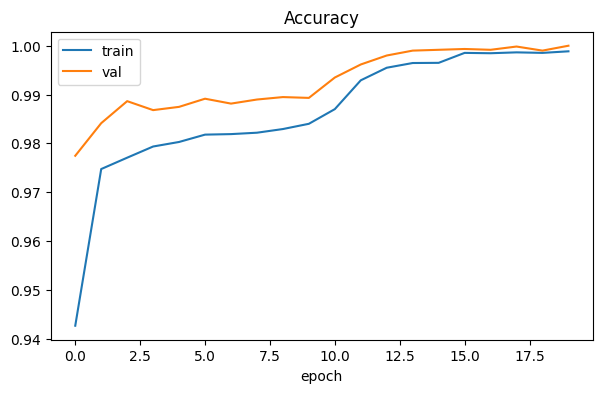

Model & label encoder tersimpan.


In [ ]:
import json, pickle, os
import matplotlib.pyplot as plt

os.makedirs("/content/PeekMyFruit/models", exist_ok=True)
os.makedirs("/content/PeekMyFruit/outputs", exist_ok=True)

model.save("/content/PeekMyFruit/models/peekmyfruit_model.keras")

mapping = {str(i): n for i, n in enumerate(class_names)}
json.dump(mapping, open("/content/PeekMyFruit/models/label_encoder.json", "w"), indent=2)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder(); le.fit(class_names)
pickle.dump(le, open("/content/PeekMyFruit/models/label_encoder.pkl", "wb"))

acc = h1.history["accuracy"] + h2.history["accuracy"]
val = h1.history["val_accuracy"] + h2.history["val_accuracy"]
plt.figure(figsize=(7, 4))
plt.plot(acc, label="train"); plt.plot(val, label="val")
plt.title("Accuracy"); plt.xlabel("epoch"); plt.legend()
plt.savefig("/content/PeekMyFruit/outputs/training_history.png", dpi=120)
plt.show()
print("Model & label encoder tersimpan.")


## Langkah 9 — Evaluasi (Accuracy, Precision, Recall, F1, Confusion Matrix)

Accuracy : 0.9992
Precision: 0.9992
Recall   : 0.9991
F1-score : 0.9992

              precision    recall  f1-score   support

        ripe       1.00      1.00      1.00      1772
      rotten       1.00      1.00      1.00      2309
      unripe       1.00      1.00      1.00      1908

    accuracy                           1.00      5989
   macro avg       1.00      1.00      1.00      5989
weighted avg       1.00      1.00      1.00      5989



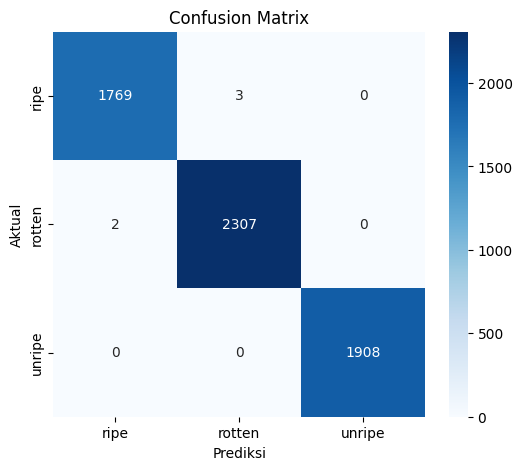

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, precision_recall_fscore_support)

y_true, y_pred = [], []
for imgs, lbls in test_ds:
    p = model.predict(imgs, verbose=0)
    y_pred.extend(np.argmax(p, axis=1))
    y_true.extend(lbls.numpy())
y_true = np.array(y_true); y_pred = np.array(y_pred)

acc = accuracy_score(y_true, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}\n")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Prediksi"); plt.ylabel("Aktual"); plt.title("Confusion Matrix")
plt.savefig("/content/PeekMyFruit/outputs/confusion_matrix.png", dpi=120)
plt.show()


## Langkah 10 — Simpan hasil ke Google Drive (PENTING)

Colab menghapus semua file ketika sesi berakhir. Jadi kita salin model ke
Google Drive supaya tidak hilang. Saat menjalankan sel ini, akan muncul jendela
minta izin akses Google Drive — klik **izinkan / allow**.

Setelah selesai, buka Google Drive kamu → folder **PeekMyFruit_hasil** →
download file **peekmyfruit_model.keras** dan **label_encoder.json** ke laptop
(taruh di folder `models` pada project PeekMyFruit di laptopmu) untuk dipakai web app.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import shutil, os
dest = "/content/drive/MyDrive/PeekMyFruit_hasil"
os.makedirs(dest, exist_ok=True)
for f in ["models/peekmyfruit_model.keras", "models/label_encoder.json",
          "models/label_encoder.pkl", "outputs/confusion_matrix.png",
          "outputs/training_history.png"]:
    shutil.copy(f"/content/PeekMyFruit/{f}", dest)
print("Semua hasil tersimpan ke Google Drive di folder:", dest)


Mounted at /content/drive
Semua hasil tersimpan ke Google Drive di folder: /content/drive/MyDrive/PeekMyFruit_hasil
